Saving lighting_split.jpg to lighting_split (15).jpg
=== Lighting Reward Model (Improved v3) ===
Top half (backlight): Reward = 0.4325
Metrics: {'brightness': np.float64(118.40532694876326), 'contrast': np.float64(122.14530835896007), 'detail': np.float64(3.429542527298559)}
Bottom half (front light): Reward = 0.4128
Metrics: {'brightness': np.float64(111.80504229328622), 'contrast': np.float64(114.80214423299194), 'detail': np.float64(3.3975990674371626)}
Difference (bottom - top): -0.0197


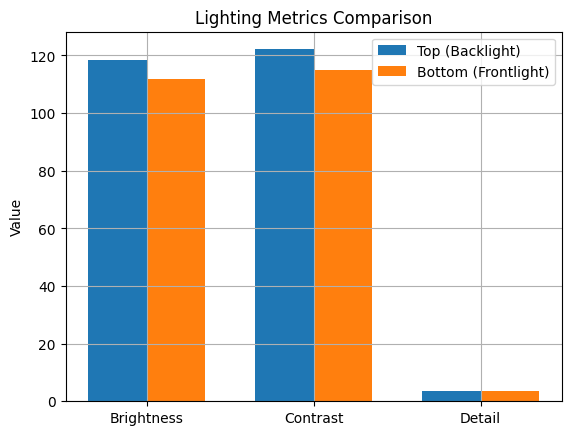

In [16]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

# Upload the image
uploaded = files.upload()

# Load the image
img = Image.open(list(uploaded.keys())[0]).convert('RGB')
img_array = np.array(img)

# Convert to luminance (real perceived brightness)
def rgb_to_luminance(image):
    return np.dot(image[..., :3], [0.2126, 0.7152, 0.0722])

# Split the image
height, width, _ = img_array.shape
top_half = img_array[:height//2]
bottom_half = img_array[height//2:]

def calculate_reward(image):
    gray = rgb_to_luminance(image)

    brightness = np.mean(gray)
    contrast = np.std(gray)

    # Edge strength for detail (sharpness)
    gy, gx = np.gradient(gray)
    edge_strength = np.mean(np.sqrt(gx**2 + gy**2))

    # Normalized values
    brightness_norm = brightness / 255.0
    contrast_norm = min(contrast / 64.0, 1.0)
    detail_norm = min(edge_strength / 20.0, 1.0)

    reward = (
        0.75 * brightness_norm +     # Strong boost for brightness
        0.05 * contrast_norm +        # Very small weight for contrast
        0.20 * detail_norm            # Good weight for sharpness/detail
    )

    reward = np.clip(reward, 0.0, 1.0)

    return reward, {
        'brightness': brightness,
        'contrast': contrast,
        'detail': edge_strength
    }

# Calculate results
top_reward, top_metrics = calculate_reward(top_half)
bottom_reward, bottom_metrics = calculate_reward(bottom_half)

print("=== Lighting Reward Model (Improved v3) ===")
print(f"Top half (backlight): Reward = {top_reward:.4f}")
print(f"Metrics: {top_metrics}")
print(f"Bottom half (front light): Reward = {bottom_reward:.4f}")
print(f"Metrics: {bottom_metrics}")
print(f"Difference (bottom - top): {bottom_reward - top_reward:.4f}")

# Bar chart
labels = ['Brightness', 'Contrast', 'Detail']
top_vals = [top_metrics['brightness'], top_metrics['contrast'], top_metrics['detail']]
bottom_vals = [bottom_metrics['brightness'], bottom_metrics['contrast'], bottom_metrics['detail']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, top_vals, width, label='Top (Backlight)')
ax.bar(x + width/2, bottom_vals, width, label='Bottom (Frontlight)')

ax.set_ylabel('Value')
ax.set_title('Lighting Metrics Comparison')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True)

plt.show()